# Efficiency and Fairness per model

In [76]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Classes.bar import Bar
from Config.config import PATHS

In [77]:
def plot_stability(list_of_alternations, list_of_titles, num_rounds):
	fig, axes = plt.subplots(len(list_of_alternations))
	for i, alternations in enumerate(list_of_alternations):
		# Detect number of agents
		num_agents = len(alternations[0])
		# Create bar object
		bar = Bar(
			num_agents=num_agents,
			threshold=0.5
		)
		bar.history = alternations * (num_rounds // len(alternations)) + alternations[:num_rounds % len(alternations)]
		attendance_file_name = None #'alternations.png'
		bar.render(
			ax=axes[i],
			file=attendance_file_name,
			num_rounds=len(bar.history)
		)
#		axes[i].imshow(plt.imread(attendance_file_name))
		if list_of_titles is not None:
			axes[i].set_title(list_of_titles[i])
		axes[i].axis('off')
	return fig


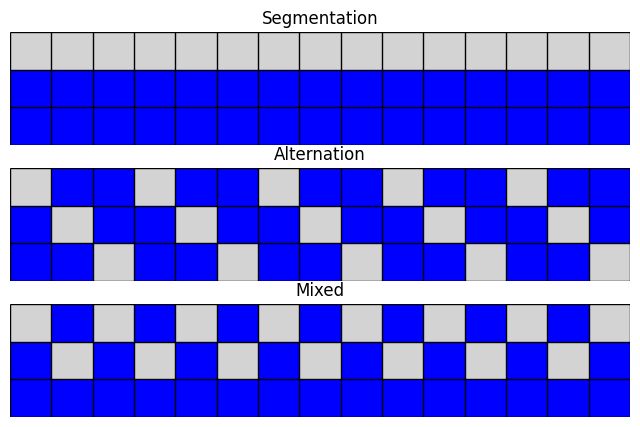

In [88]:
num_rounds = 15
list_of_alternations = [
	# [np.random.randint(0, 2, 3).tolist() for _ in range(num_rounds)],
	[[1, 1, 0]],
	[[1, 1, 0], [1, 0, 1], [0, 1, 1]],
	[[1, 1, 0], [1, 0, 1]],
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['Segmentation', 'Alternation', 'Mixed'],
    num_rounds=num_rounds
)
fig.set_size_inches(8, 5)
fig.savefig(PATHS['exploratory_figures'] / 'Coordination_types.png', dpi=300)

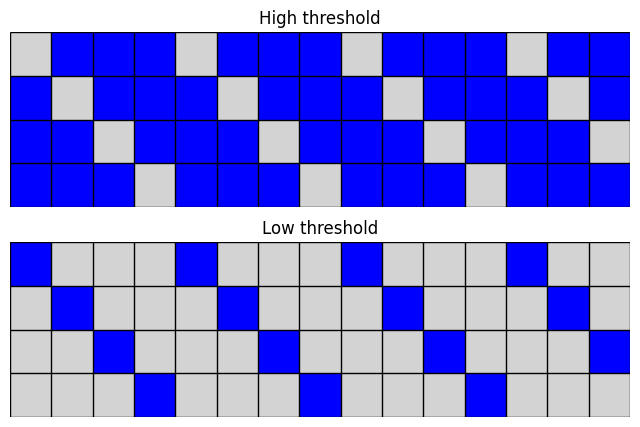

In [ ]:
num_rounds = 15
list_of_alternations = [
	[[1, 1, 1, 0], [1, 1, 0, 1], [1, 0, 1, 1], [0, 1, 1, 1]],
	[[0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0], [1, 0, 0, 0]],
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['High threshold', 'Low threshold'],
    num_rounds=num_rounds
)
fig.set_size_inches(8, 5.5)
fig.savefig(PATHS['exploratory_figures'] / 'Symmetry_of_coordination.png', dpi=300)

In [80]:
from Utils.cherrypick_simulations import CherryPickEquilibria

list_num_agents = [2, 4, 6, 8]
thresholds = [0.34, 0.5, 0.75]
kinds = ['alternation', 'mixed', 'random', 'segmentation']
df_list = []

for num_agents in list_num_agents:

    for threshold in thresholds:

        if threshold * num_agents < 1:
            continue

        equilibria = CherryPickEquilibria(
            num_agents=num_agents,
            threshold = threshold,
            epsilon=0,
            num_rounds=50,
            num_episodes=30,
            allow_shuffle=True,
        )

        for kind in kinds:
            if kind == 'mixed':

                if num_agents == 2:
                    continue
                if threshold * num_agents < 2:
                    continue

            df = equilibria.generate_data(kind)
            df_list.append(df)

df = pd.concat(df_list, ignore_index=True)


Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

...

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

In [81]:
from Utils.utils import GetMeasurements

gm = GetMeasurements(
    data=df,
    measures=[
        'bounded_efficiency', 'gini_index', 
        'entropy', 'conditional_entropy', 
        'min_entropy',
    ]
)
gm.columns.append('kind')
df_measures = gm.get_measurements()

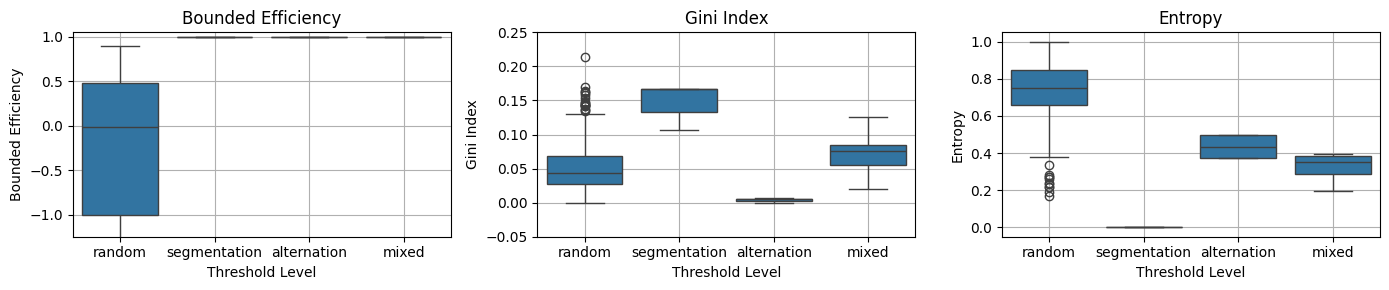

In [82]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3), tight_layout=True)

sns.boxplot(
    data=df_measures,
    x="kind",
    y="bounded_efficiency",
    ax=ax[0],
    order=["random", "segmentation", "alternation", "mixed"],
)
ax[0].set_ylim(-1.25, 1.05)
ax[0].set_title(r"Bounded Efficiency")
ax[0].set_xlabel("Threshold Level")
ax[0].set_ylabel("Bounded Efficiency")

sns.boxplot(
    data=df_measures,
    x="kind",
    y="gini_index",
    ax=ax[1],
    order=["random", "segmentation", "alternation", "mixed"],
)
ax[1].set_ylim(-0.05, 0.25)
ax[1].set_title(r"Gini Index")
ax[1].set_xlabel("Threshold Level")
ax[1].set_ylabel("Gini Index")

sns.boxplot(
    data=df_measures,
    x="kind",
    y="entropy",
    ax=ax[2],
    order=["random", "segmentation", "alternation", "mixed"],
)
ax[2].set_ylim(-0.05, 1.05)
ax[2].set_title(r"Entropy")
ax[2].set_xlabel("Threshold Level")
ax[2].set_ylabel("Entropy")

for ax_ in ax:
    ax_.grid()

plt.show()
fig.savefig(PATHS['exploratory_figures'] / 'measurements.png', dpi=300)

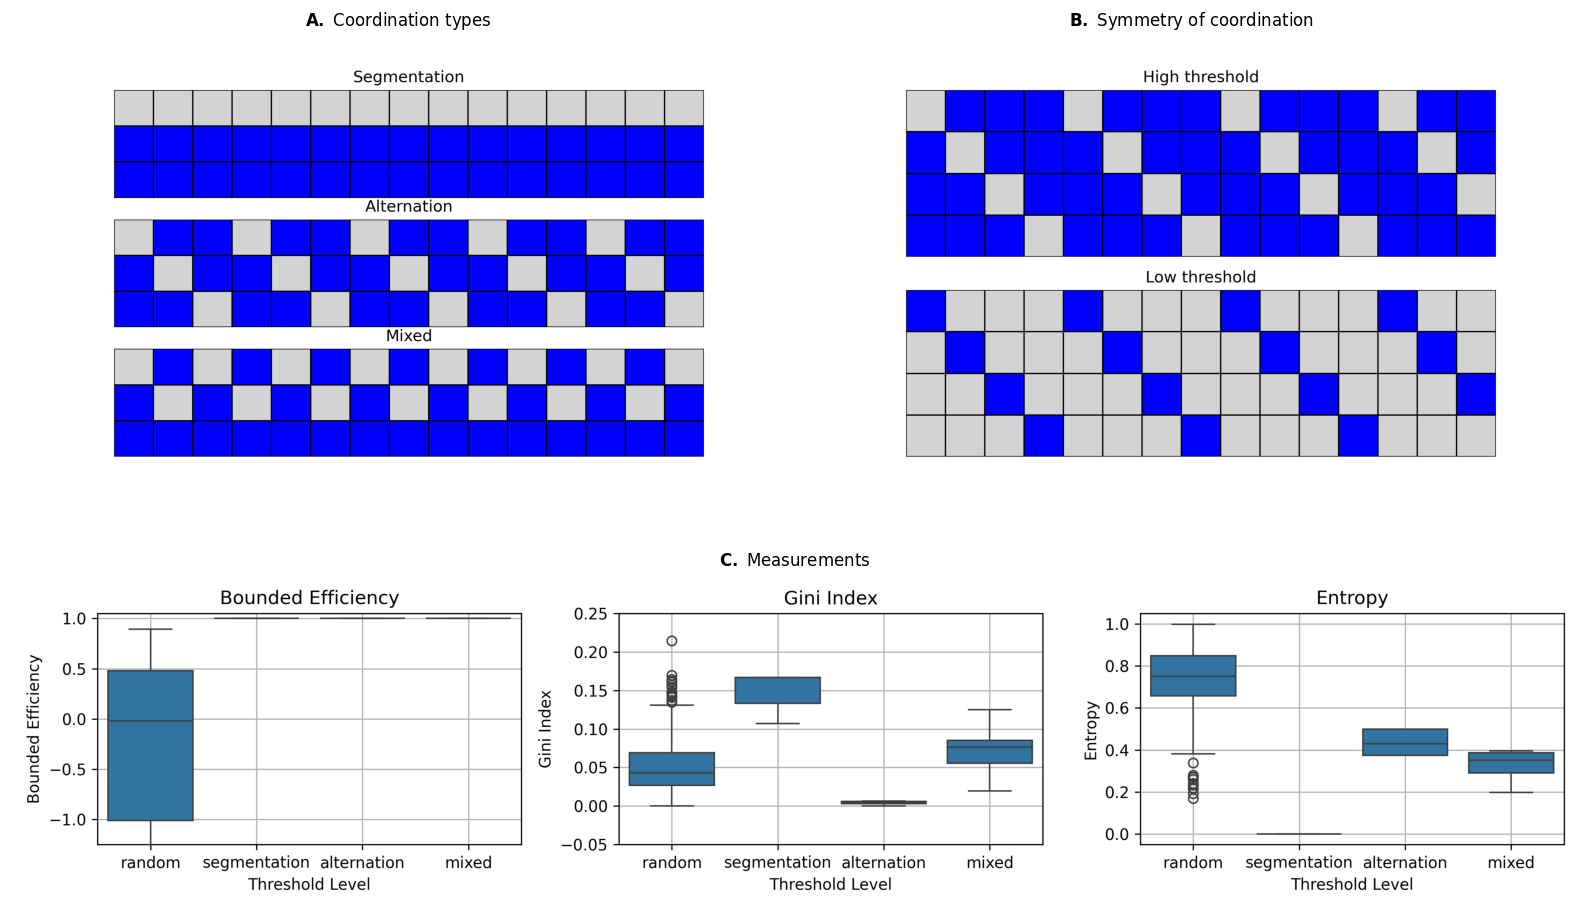

In [89]:
fig = plt.figure(figsize=(16, 10))

# Create a 2x2 grid
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row (spanning)
ax3 = fig.add_subplot(gs[1, :])

ax1.imshow(plt.imread(PATHS['exploratory_figures'] / 'Coordination_types.png'))
ax1.set_title(r'$\bf{A.}$ Coordination types')

ax2.imshow(plt.imread(PATHS['exploratory_figures'] / 'Symmetry_of_coordination.png'))
ax2.set_title(r'$\bf{B.}$ Symmetry of coordination')

ax3.imshow(plt.imread(PATHS['exploratory_figures'] / 'measurements.png'))
ax3.set_title(r'$\bf{C.}$ Measurements')

for ax in [ax1, ax2, ax3]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(PATHS['exploratory_figures'] / 'Fig1.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()